In [2]:
# reading the data 
data = pd.read_csv(r"C:\Users\punee\Downloads\archive (77).zip")

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [4]:
# data cleaning 
data.shape

(13580, 21)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [6]:
# data cleaning 
data.drop_duplicates(inplace=True)
data.reset_index()

,index,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [7]:
data.shape

(13580, 21)

In [8]:
# check for null values counts
null_counts = data.isnull().sum()
if null_counts.sum() >0:
    print(null_counts[null_counts>0])

Car               62
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
dtype: int64


In [9]:
data = data[data['Car'].notna()]

In [10]:
#replace the Building Area 
data['BuildingArea'] = data["BuildingArea"].fillna(data['BuildingArea'].median())
data['YearBuilt'] = data['YearBuilt'].fillna(data['YearBuilt'].median())

In [11]:
data.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                 0
Landsize            0
BuildingArea        0
YearBuilt           0
CouncilArea      1307
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [12]:
data = data[data['CouncilArea'].notna()]

In [13]:
data.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12211 entries, 0 to 12212
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         12211 non-null  object 
 1   Address        12211 non-null  object 
 2   Rooms          12211 non-null  int64  
 3   Type           12211 non-null  object 
 4   Price          12211 non-null  float64
 5   Method         12211 non-null  object 
 6   SellerG        12211 non-null  object 
 7   Date           12211 non-null  object 
 8   Distance       12211 non-null  float64
 9   Postcode       12211 non-null  float64
 10  Bedroom2       12211 non-null  float64
 11  Bathroom       12211 non-null  float64
 12  Car            12211 non-null  float64
 13  Landsize       12211 non-null  float64
 14  BuildingArea   12211 non-null  float64
 15  YearBuilt      12211 non-null  float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      12211 non-null  float64
 18  Longtitude 

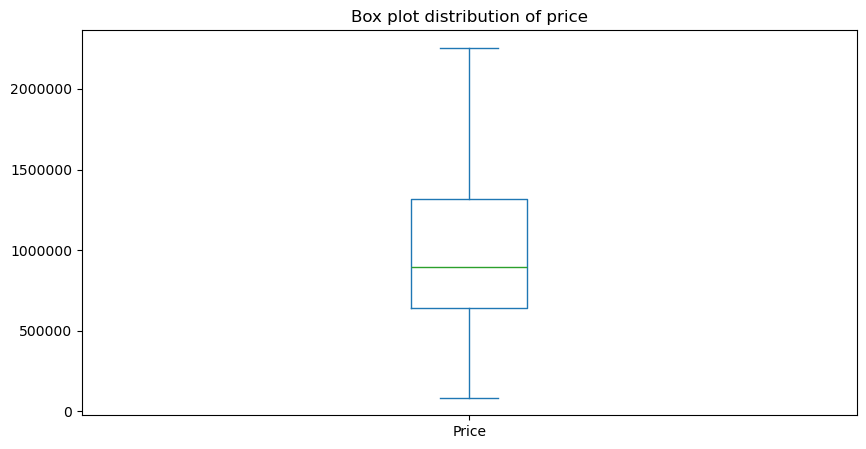

In [207]:
# check for the outlier
plt.figure(figsize=(10,5))
data['Price'].plot(kind="box")
plt.ticklabel_format(style='plain', axis='y')
plt.title(f"Box plot distribution of price")
plt.show()

In [16]:
data = data[data['Price']<8000000]

In [17]:
z_score = np.abs((data["Price"] - data["Price"].mean()) / data["Price"].std())

In [19]:
z_score = np.abs((data["Price"] - data["Price"].mean()) / data["Price"].std())


outlier_threshold = 3


outliers = data[z_score > outlier_threshold]

In [20]:
# apply 95 percentile 
Price_percentle = data['Price'].quantile(.95)

In [21]:
data['Price'] = np.where(data['Price'] > Price_percentle  ,Price_percentle , data['Price'])


In [109]:
# handling the outlier in land 
data = data[data['Landsize']<400000]
z_score = np.abs((data[['Landsize',"BuildingArea"]] - data[['Landsize',"BuildingArea"]].mean()) / data[['Landsize',"BuildingArea"]].std())

outlier_threshold = 3
outlier_2 = data[z_score>outlier_threshold]

landsize_percentle = data['Landsize'].quantile(.95)
Building_percentle = data['BuildingArea'].quantile(.95)

In [113]:
data['Landsize'] = np.where(data['Landsize'] > landsize_percentle , landsize_percentle , data['Landsize'])
data['BuildingArea'] = np.where(data['BuildingArea'] > Building_percentle , Building_percentle , data["BuildingArea"])

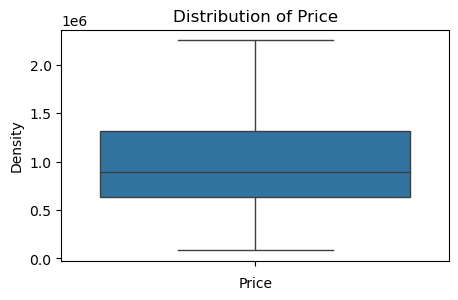

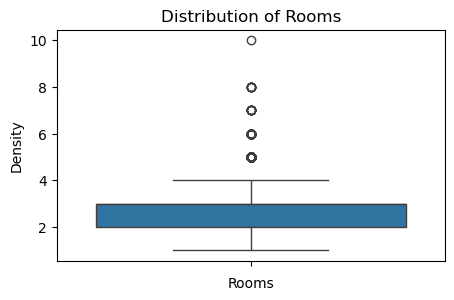

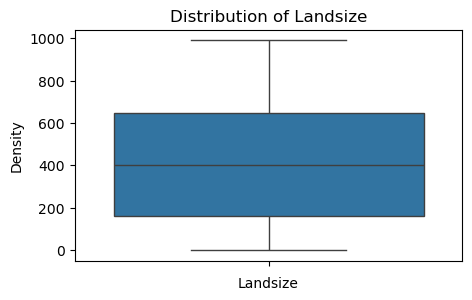

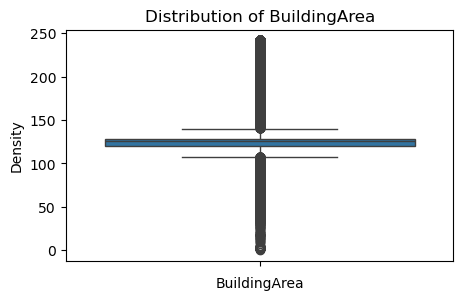

In [209]:
 def display_plot(data, row):  
    plt.figure(figsize=(5, 3))  
    sns.boxplot(data[row], )  
    plt.title(f'Distribution of {row}')  
    plt.xlabel(row)  
    plt.ylabel('Density')  
    plt.show()  

columns_to_plot = ["Price", "Rooms", "Landsize", "BuildingArea"]

for col in columns_to_plot:
    display_plot(data, col)

In [203]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12208 entries, 0 to 12212
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         12208 non-null  object        
 1   Address        12208 non-null  object        
 2   Rooms          12208 non-null  int64         
 3   Type           12208 non-null  object        
 4   Price          12208 non-null  float64       
 5   Method         12208 non-null  object        
 6   SellerG        12208 non-null  object        
 7   Date           12208 non-null  datetime64[ns]
 8   Distance       12208 non-null  float64       
 9   Postcode       12208 non-null  int32         
 10  Bedroom2       12208 non-null  int32         
 11  Bathroom       12208 non-null  int32         
 12  Car            12208 non-null  int32         
 13  Landsize       12208 non-null  float64       
 14  BuildingArea   12208 non-null  float64       
 15  YearBuilt      12207 non

In [201]:
data['Propertycount']

0        4019
1        4019
2        4019
3        4019
4        4019
         ... 
12208    6380
12209    4380
12210    2940
12211    6543
12212    6543
Name: Propertycount, Length: 12208, dtype: int32

In [325]:
# data type conversion 
data["Date"] = pd.to_datetime(data["Date"], format="%d/%m/%Y")
data['Postcode'] = data['Postcode'].astype("int")
data['Bedroom2'] = data['Bedroom2'].astype("int")
data['Bathroom'] = data['Bathroom'].astype("int")
data['Car'] = data['Car'].astype("int")
data['Propertycount'] = data['Propertycount'].astype("int")

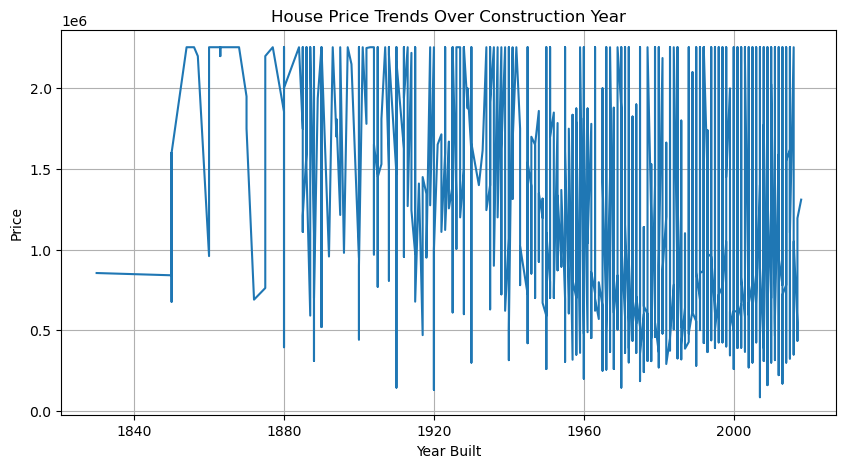

In [375]:
# time series analysis 
data['YearBuilt'] = pd.to_datetime(data['YearBuilt'], format='%Y')


data = data.sort_values(by='YearBuilt')

plt.figure(figsize=(10, 5))
plt.plot(data['YearBuilt'], data['Price'],  linestyle='-')

# Labels & title

plt.title("House Price Trends Over Construction Year")
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.grid()
plt.show()


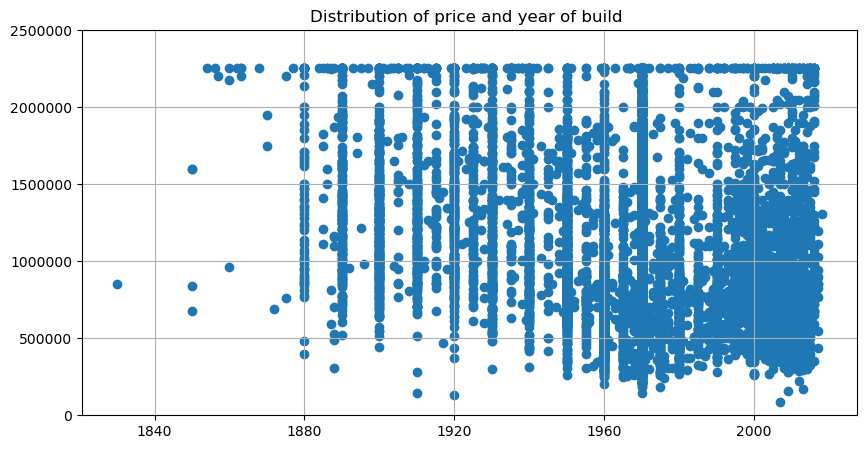

In [371]:
# sactter plot of price and year of build

plt.figure(figsize=(10,5))
plt.scatter(x = data['YearBuilt'] , y=data['Price'])
plt.ticklabel_format(style='plain', axis='y')
plt.title("Distribution of price and year of build ")
plt.ylim(0,2500000)
plt.grid()
plt.show()

In [395]:
# year and average price 
data.columns
data['YearBuilt'] = data['YearBuilt'].dt.year


Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [399]:
pd.set_option('display.float_format', '{:.2f}'.format)  # Show 2 decimal places

Year_avgPrice=data.groupby(["YearBuilt"])['Price'].mean().reset_index()

In [405]:
Year_avgPrice = Year_avgPrice.sort_values(by="YearBuilt")

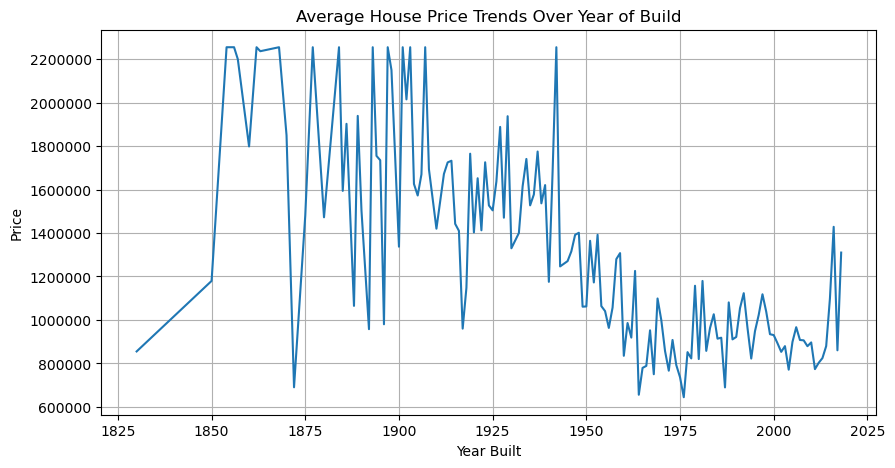

In [417]:
plt.figure(figsize=(10, 5))
plt.plot(Year_avgPrice['YearBuilt'], Year_avgPrice['Price'],  linestyle='-' )
plt.title("Average House Price Trends Over Year of Build")
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.ticklabel_format(style='plain', axis='y')
plt.grid()
plt.show()

In [ ]:
# developing model 

In [211]:
data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [249]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [283]:
# setting the independant and dependant variables

X = data[['Rooms', 'Landsize', 'Distance', 'Bathroom', 'BuildingArea', 'Bedroom2', 'Car' , "Postcode" , 'YearBuilt']]
y = data['Price']

In [311]:
X['Postcode'] = pd.to_numeric(X['Postcode'], errors='coerce')
X['YearBuilt'] = pd.to_numeric(X['YearBuilt'], errors='coerce')
X = X.fillna(X.median())
X['Lattitude'] = data['Lattitude']
X['Longtitude'] = data['Longtitude']

In [315]:
# train test split 
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 , random_state=42)

In [317]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train , y_train)

RandomForestRegressor(random_state=42)

In [319]:
y_predicted =model.predict(X_test)

In [423]:
mae = mean_absolute_error(y_test,y_predicted )
r2 = r2_score(y_test, y_predicted)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Absolute Error: 141161.58897927147
R-squared: 0.8495025478557156
